# Part 3: Structured Pruning (정형 프루닝)

## 이 노트북에서 다루는 내용
1. Structured Pruning의 핵심 개념
2. Ln Structured Pruning (필터 단위 제거)
3. Random Structured Pruning
4. Fine-tuning (pruning 후 재학습)
5. Sparsity별 정확도 변화 (Fine-tuning 포함)

---

## Structured Pruning vs Unstructured Pruning

| 특성 | Unstructured | Structured |
|------|-------------|------------|
| 단위 | 개별 가중치 | 필터/채널 |
| 압축률 | 높음 | 중간 |
| 속도 향상 | 제한적 (sparse) | **실질적** |
| 정확도 유지 | 좋음 | 상대적으로 어려움 |
| HW 지원 | 특수 HW 필요 | **범용 HW 가능** |

### Ln Structured Pruning
- Conv2d 필터의 **Ln norm** 기준으로 중요도 판단
- L1 norm: `Σ|w|` → 가중치 절대값의 합
- L2 norm: `√(Σw²)` → 가중치 크기
- **norm이 작은 필터 = 출력 feature map에 기여도 낮음**

### Fine-tuning
- Pruning 후 정확도 하락을 회복하기 위한 **소량의 추가 학습**
- 일반적으로 원래 학습률의 **1/10**로 fine-tuning
- Pipeline: `Pruning → Fine-tuning → (반복 가능)`

## 1. 환경 설정 및 Import

In [1]:
import copy

import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

from module.models import CNN

In [2]:
def get_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


DEVICE = get_device()
print(f"Using device: {DEVICE}")

BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 0.001
NUM_CLASSES = 10

PRUNING_AMOUNT = 0.3   # 30% 필터 제거
FINETUNE_EPOCHS = 3    # Fine-tuning 에포크
FINETUNE_LR = 0.0001   # Fine-tuning 학습률 (원래의 1/10)

SEED = 42
torch.manual_seed(SEED)

Using device: cuda


## 2. 데이터 로드 및 유틸리티 함수

In [3]:
def get_data_loaders(batch_size: int = 128) -> tuple[DataLoader, DataLoader]:
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    train_dataset = datasets.CIFAR10(root='./data/datasets', train=True, download=True, transform=transform)
    test_dataset = datasets.CIFAR10(root='./data/datasets', train=False, download=True, transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=0, pin_memory=True if DEVICE == "cuda" else False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                             num_workers=0, pin_memory=True if DEVICE == "cuda" else False)
    return train_loader, test_loader


def test(model, test_loader, device):
    model.to(device)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total


def train_baseline(model, train_loader, epochs, lr, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.to(device)
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"    Epoch {epoch + 1}/{epochs}, Loss: {running_loss / len(train_loader):.4f}")


def get_sparsity(model):
    total_params = 0
    zero_params = 0
    layer_sparsity = {}
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            weight = module.weight.data
            total = weight.numel()
            zeros = (weight == 0).sum().item()
            total_params += total
            zero_params += zeros
            if total > 0:
                layer_sparsity[name] = {'total': total, 'zeros': zeros, 'sparsity': zeros / total * 100}
    return zero_params / total_params * 100 if total_params > 0 else 0


def remove_pruning(model):
    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            try:
                prune.remove(module, 'weight')
            except ValueError:
                pass
    return model

In [4]:
print("[1] 데이터 로드 중...")
train_loader, test_loader = get_data_loaders(BATCH_SIZE)

[1] 데이터 로드 중...


## 3. Baseline 모델 로드

In [5]:
print("[2] Baseline 모델 준비...")
model = CNN(num_classes=NUM_CLASSES).to(DEVICE)

try:
    model.load_state_dict(torch.load('./data/trained_models/baseline_model.pth', map_location=DEVICE, weights_only=True))
    print("    저장된 Baseline 모델 로드 완료")
except FileNotFoundError:
    print("    저장된 모델 없음. 학습 시작...")
    torch.manual_seed(SEED)
    model = CNN(num_classes=NUM_CLASSES).to(DEVICE)
    train_baseline(model, train_loader, EPOCHS, LEARNING_RATE, DEVICE)
    torch.save(model.state_dict(), './data/trained_models/baseline_model.pth')

baseline_accuracy = test(model, test_loader, DEVICE)
print(f"Baseline Accuracy: {baseline_accuracy:.2f}%")

[2] Baseline 모델 준비...
    저장된 Baseline 모델 로드 완료
Baseline Accuracy: 75.01%


## 4. 필터별 L1 Norm 시각화

각 Conv2d 레이어의 필터별 L1 norm을 시각화합니다.
- **빨간 막대**: 하위 30% (pruning 대상)
- **파란 막대**: 상위 70% (유지)

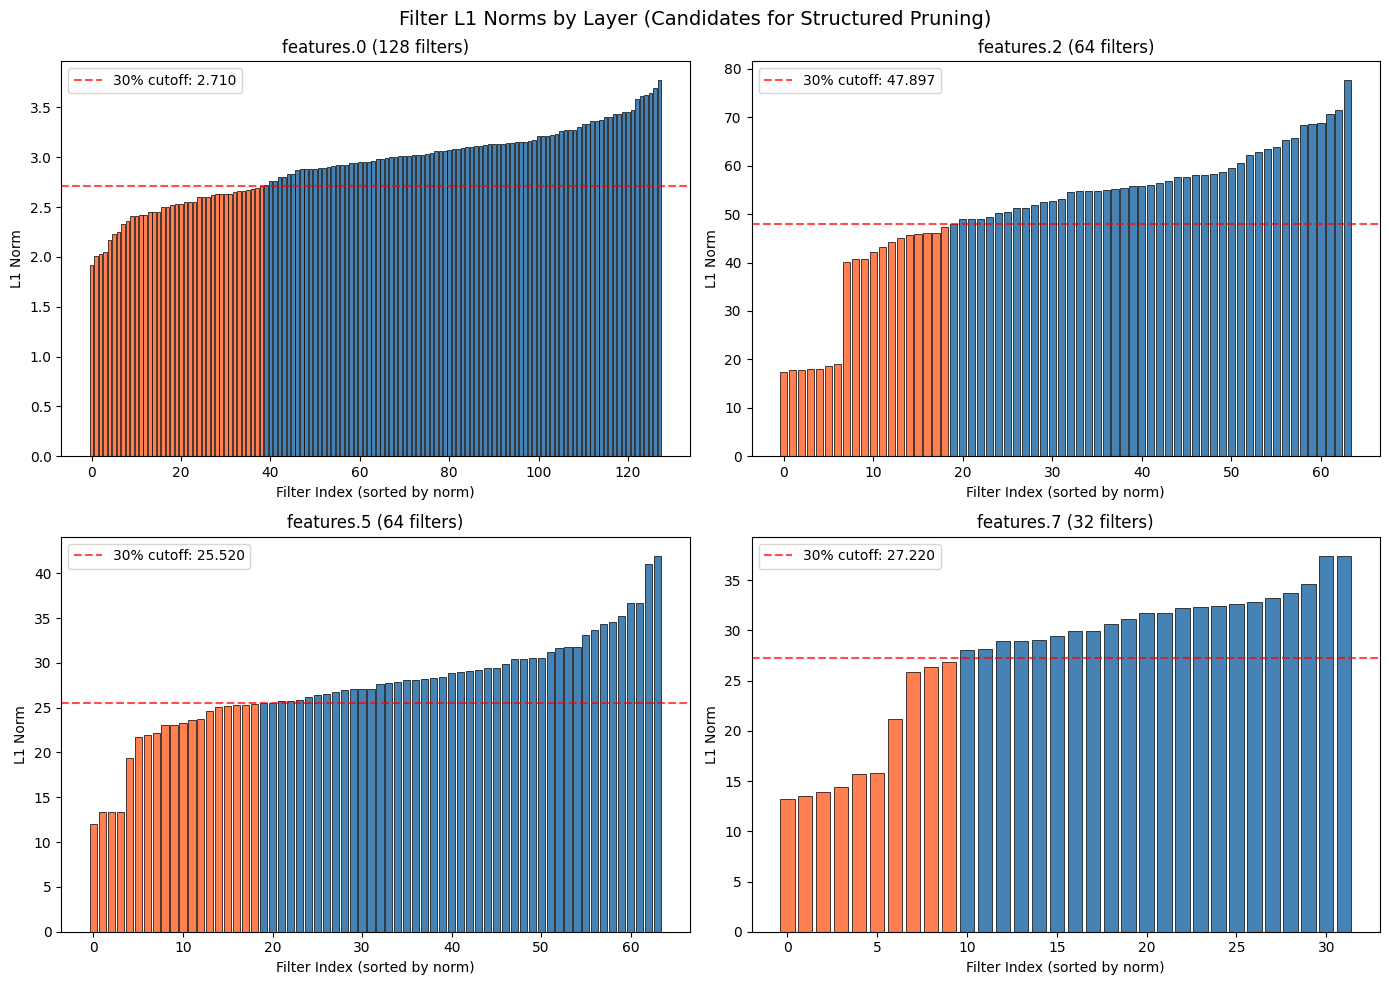

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Filter L1 Norms by Layer (Candidates for Structured Pruning)', fontsize=14)

conv_layers = [(n, m) for n, m in model.named_modules() if isinstance(m, nn.Conv2d)]

for idx, (name, layer) in enumerate(conv_layers[:4]):
    ax = axes[idx // 2][idx % 2]
    weight = layer.weight.data.cpu()
    filter_norms = weight.abs().sum(dim=[1, 2, 3]).numpy()
    sorted_norms = np.sort(filter_norms)
    colors = ['coral' if n < np.percentile(filter_norms, 30) else 'steelblue' for n in sorted_norms]

    ax.bar(range(len(sorted_norms)), sorted_norms, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(f'{name} ({layer.weight.shape[0]} filters)')
    ax.set_xlabel('Filter Index (sorted by norm)')
    ax.set_ylabel('L1 Norm')
    cutoff = np.percentile(filter_norms, 30)
    ax.axhline(y=cutoff, color='red', linestyle='--', alpha=0.7, label=f'30% cutoff: {cutoff:.3f}')
    ax.legend()

plt.tight_layout()
plt.show()

## 5. L1 Structured Pruning

```python
prune.ln_structured(module, name='weight', amount=0.3, n=1, dim=0)
# dim=0: output channel(필터) 단위로 pruning
# n=1: L1 norm 사용
```

필터 전체가 0이 되므로 실제 연산량 감소에 직접적으로 기여합니다.

In [7]:
print(f"[3] L1 Structured Pruning ({PRUNING_AMOUNT * 100:.0f}% 필터 제거)")
print("-" * 40)

l1_model = copy.deepcopy(model)
for name, module in l1_model.named_modules():
    if isinstance(module, nn.Conv2d):
        prune.ln_structured(module, name='weight', amount=PRUNING_AMOUNT, n=1, dim=0)
l1_model = remove_pruning(l1_model)

l1_accuracy = test(l1_model, test_loader, DEVICE)
l1_sparsity = get_sparsity(l1_model)
print(f"L1 Structured Accuracy: {l1_accuracy:.2f}% (변화: {l1_accuracy - baseline_accuracy:+.2f}%)")
print(f"Sparsity: {l1_sparsity:.1f}%")

[3] L1 Structured Pruning (30% 필터 제거)
----------------------------------------
L1 Structured Accuracy: 64.76% (변화: -10.25%)
Sparsity: 3.3%


## 6. L2 Structured Pruning

In [8]:
print(f"[4] L2 Structured Pruning ({PRUNING_AMOUNT * 100:.0f}% 필터 제거)")
print("-" * 40)

l2_model = copy.deepcopy(model)
for name, module in l2_model.named_modules():
    if isinstance(module, nn.Conv2d):
        prune.ln_structured(module, name='weight', amount=PRUNING_AMOUNT, n=2, dim=0)
l2_model = remove_pruning(l2_model)

l2_accuracy = test(l2_model, test_loader, DEVICE)
print(f"L2 Structured Accuracy: {l2_accuracy:.2f}% (변화: {l2_accuracy - baseline_accuracy:+.2f}%)")

[4] L2 Structured Pruning (30% 필터 제거)
----------------------------------------
L2 Structured Accuracy: 65.78% (변화: -9.23%)


## 7. Random Structured Pruning

In [9]:
print(f"[5] Random Structured Pruning ({PRUNING_AMOUNT * 100:.0f}% 필터 제거)")
print("-" * 40)

random_model = copy.deepcopy(model)
for name, module in random_model.named_modules():
    if isinstance(module, nn.Conv2d):
        prune.random_structured(module, name='weight', amount=PRUNING_AMOUNT, dim=0)
random_model = remove_pruning(random_model)

random_accuracy = test(random_model, test_loader, DEVICE)
print(f"Random Structured Accuracy: {random_accuracy:.2f}% (변화: {random_accuracy - baseline_accuracy:+.2f}%)")

[5] Random Structured Pruning (30% 필터 제거)
----------------------------------------
Random Structured Accuracy: 55.08% (변화: -19.93%)


## 8. Fine-tuning 효과 검증

Pruning 후 소량의 추가 학습으로 정확도를 회복합니다.

- Fine-tune Epochs: 3
- Fine-tune LR: 0.0001 (원래의 1/10)

In [10]:
def fine_tune(model, train_loader, epochs, lr, device):
    """Pruning 후 Fine-tuning"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.to(device)
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"    Fine-tune Epoch {epoch + 1}/{epochs}, Loss: {running_loss / len(train_loader):.4f}")

In [11]:
print(f"[6] Fine-tuning 효과 (L1 Structured + Fine-tune)")
print("-" * 40)

ft_model = copy.deepcopy(model)
for name, module in ft_model.named_modules():
    if isinstance(module, nn.Conv2d):
        prune.ln_structured(module, name='weight', amount=PRUNING_AMOUNT, n=1, dim=0)

# mask 유지 상태에서 평가 (pruning 직후 정확도)
before_ft_accuracy = test(ft_model, test_loader, DEVICE)
print(f"Fine-tune 전: {before_ft_accuracy:.2f}%")

# mask 유지한 채 fine-tuning (pruned 가중치 0 유지)
fine_tune(ft_model, train_loader, FINETUNE_EPOCHS, FINETUNE_LR, DEVICE)

# fine-tuning 완료 후 mask 영구 적용
ft_model = remove_pruning(ft_model)
after_ft_accuracy = test(ft_model, test_loader, DEVICE)
print(f"Fine-tune 후: {after_ft_accuracy:.2f}% (회복: {after_ft_accuracy - before_ft_accuracy:+.2f}%)")

[6] Fine-tuning 효과 (L1 Structured + Fine-tune)
----------------------------------------
Fine-tune 전: 64.76%
    Fine-tune Epoch 1/3, Loss: 0.1896
    Fine-tune Epoch 2/3, Loss: 0.0879
    Fine-tune Epoch 3/3, Loss: 0.0591
Fine-tune 후: 76.12% (회복: +11.36%)


In [12]:
# Fine-tuned 모델 저장
torch.save(ft_model.state_dict(), './data/trained_models/structured_pruned_finetuned.pth')
print("Fine-tuned 모델 저장: ./data/trained_models/structured_pruned_finetuned.pth")

Fine-tuned 모델 저장: ./data/trained_models/structured_pruned_finetuned.pth


## 9. Sparsity별 정확도 변화 (Structured, with Fine-tuning)

Pruning 비율을 변화시키며 Fine-tuning 전후 정확도를 비교합니다.

In [14]:
print("[7] Sparsity별 정확도 변화 (L1 Structured)")
print("-" * 40)

sparsity_levels = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
structured_results = {}
structured_ft_results = {}

for amount in sparsity_levels:
    # Pruning only
    test_model = copy.deepcopy(model)
    for name, module in test_model.named_modules():
        if isinstance(module, nn.Conv2d):
            prune.ln_structured(module, name='weight', amount=amount, n=1, dim=0)
    test_model = remove_pruning(test_model)
    acc = test(test_model, test_loader, DEVICE)
    structured_results[amount * 100] = acc

    # Pruning + Fine-tuning (mask 유지한 채 fine-tuning)
    ft_model = copy.deepcopy(model)
    for name, module in ft_model.named_modules():
        if isinstance(module, nn.Conv2d):
            prune.ln_structured(module, name='weight', amount=amount, n=1, dim=0)
    fine_tune(ft_model, train_loader, FINETUNE_EPOCHS, FINETUNE_LR, DEVICE)
    ft_model = remove_pruning(ft_model)
    ft_acc = test(ft_model, test_loader, DEVICE)
    structured_ft_results[amount * 100] = ft_acc

    print(f"    Sparsity {amount * 100:5.1f}%: Pruning only {acc:.2f}% | + Fine-tune {ft_acc:.2f}%")


[7] Sparsity별 정확도 변화 (L1 Structured)
----------------------------------------
    Fine-tune Epoch 1/3, Loss: 0.0476
    Fine-tune Epoch 2/3, Loss: 0.0233
    Fine-tune Epoch 3/3, Loss: 0.0166
    Sparsity  10.0%: Pruning only 74.74% | + Fine-tune 77.45%
    Fine-tune Epoch 1/3, Loss: 0.0718
    Fine-tune Epoch 2/3, Loss: 0.0311
    Fine-tune Epoch 3/3, Loss: 0.0204
    Sparsity  20.0%: Pruning only 72.19% | + Fine-tune 77.40%
    Fine-tune Epoch 1/3, Loss: 0.1932
    Fine-tune Epoch 2/3, Loss: 0.0887
    Fine-tune Epoch 3/3, Loss: 0.0569
    Sparsity  30.0%: Pruning only 64.76% | + Fine-tune 75.77%
    Fine-tune Epoch 1/3, Loss: 0.4019
    Fine-tune Epoch 2/3, Loss: 0.2066
    Fine-tune Epoch 3/3, Loss: 0.1497
    Sparsity  40.0%: Pruning only 52.76% | + Fine-tune 74.84%
    Fine-tune Epoch 1/3, Loss: 0.6887
    Fine-tune Epoch 2/3, Loss: 0.3868
    Fine-tune Epoch 3/3, Loss: 0.3016
    Sparsity  50.0%: Pruning only 39.30% | + Fine-tune 72.88%
    Fine-tune Epoch 1/3, Loss: 0.9927
    

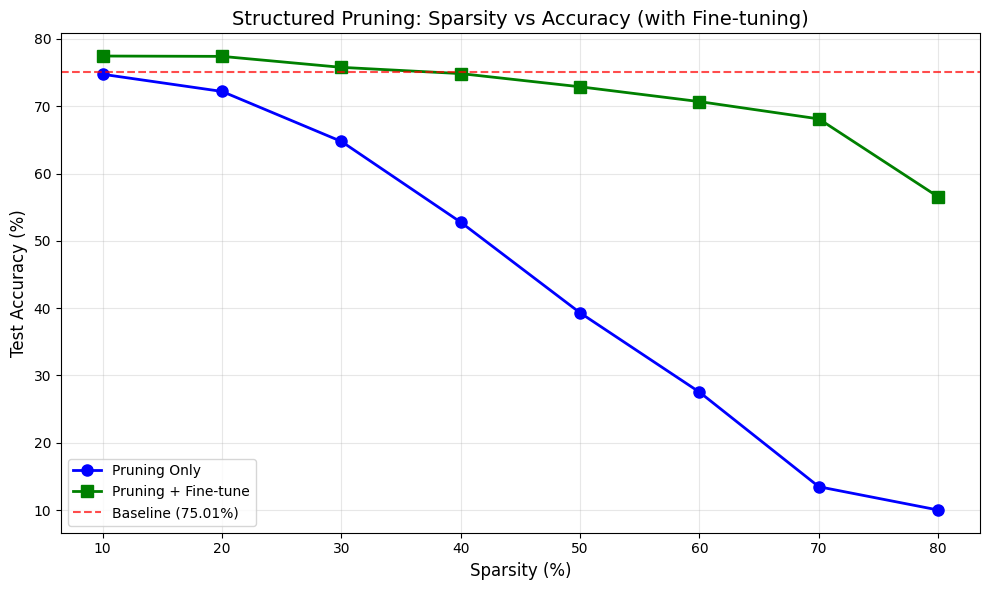

In [15]:
# Sparsity vs Accuracy 시각화 (Pruning only vs Fine-tuned)
plt.figure(figsize=(10, 6))
sparsities = list(structured_results.keys())
acc_pruned = list(structured_results.values())
acc_finetuned = list(structured_ft_results.values())

plt.plot(sparsities, acc_pruned, 'bo-', linewidth=2, markersize=8, label='Pruning Only')
plt.plot(sparsities, acc_finetuned, 'gs-', linewidth=2, markersize=8, label='Pruning + Fine-tune')
plt.axhline(y=baseline_accuracy, color='r', linestyle='--', alpha=0.7, label=f'Baseline ({baseline_accuracy:.2f}%)')

plt.xlabel('Sparsity (%)', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('Structured Pruning: Sparsity vs Accuracy (with Fine-tuning)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. 결과 요약

In [16]:
print("=" * 65)
print("결과 요약: Structured Pruning (30% 필터 제거)")
print("=" * 65)
print(f"{'방법':<40} {'정확도':<10} {'vs Baseline':<12}")
print("-" * 65)
print(f"{'Baseline (no pruning)':<40} {baseline_accuracy:>8.2f}%")
print(f"{'L1 Structured':<40} {l1_accuracy:>8.2f}% {l1_accuracy - baseline_accuracy:>+10.2f}%")
print(f"{'L2 Structured':<40} {l2_accuracy:>8.2f}% {l2_accuracy - baseline_accuracy:>+10.2f}%")
print(f"{'Random Structured':<40} {random_accuracy:>8.2f}% {random_accuracy - baseline_accuracy:>+10.2f}%")
print(f"{'L1 Structured + Fine-tune':<40} {after_ft_accuracy:>8.2f}% {after_ft_accuracy - baseline_accuracy:>+10.2f}%")
print("-" * 65)

print(f"\n분석:")
print(f"- Fine-tuning으로 {after_ft_accuracy - l1_accuracy:+.2f}% 정확도 회복")
if l1_accuracy > random_accuracy:
    print("- L1 norm 기반 pruning이 랜덤보다 효과적")
print("- Structured pruning은 실제 연산량 감소에 효과적")
print("  (0인 필터를 물리적으로 제거하면 실제 속도 향상)")

결과 요약: Structured Pruning (30% 필터 제거)
방법                                       정확도        vs Baseline 
-----------------------------------------------------------------
Baseline (no pruning)                       75.01%
L1 Structured                               64.76%     -10.25%
L2 Structured                               65.78%      -9.23%
Random Structured                           55.08%     -19.93%
L1 Structured + Fine-tune                   76.12%      +1.11%
-----------------------------------------------------------------

분석:
- Fine-tuning으로 +11.36% 정확도 회복
- L1 norm 기반 pruning이 랜덤보다 효과적
- Structured pruning은 실제 연산량 감소에 효과적
  (0인 필터를 물리적으로 제거하면 실제 속도 향상)


In [17]:
print("\n다음 노트북(04_experiment_analysis.ipynb)에서 종합 실험을 진행합니다.")


다음 노트북(04_experiment_analysis.ipynb)에서 종합 실험을 진행합니다.


---

## 다음 단계

**04_experiment_analysis.ipynb**에서는:
1. 모든 Pruning 방법 통합 비교
2. Iterative Pruning (점진적 프루닝)
3. 종합 시각화 및 분석